# Support Vector Machine

In [5]:
import numpy as np
import matplotlib.pyplot as plt
def clouds(num_points=100):
  centers=[(1, 1), (-1, -1)]
  spreads= [0.5, 0.7]
  labels =[-1, 1]
  
  X = []
  y =[]
  for center, spread, label in zip(centers, spreads, labels):
    X += np.random.multivariate_normal(center, spread*np.identity(2), num_points).tolist()
    y+=[label]*num_points
  return X, y

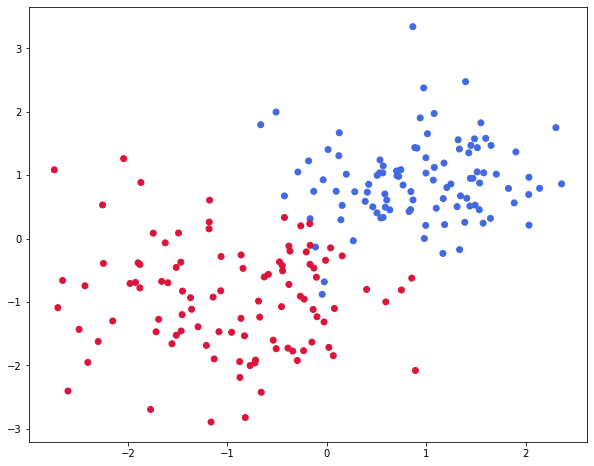

In [6]:
X, y = clouds(100)
colors= ["crimson" if label == 1 else "royalblue" for label in y]
plt.figure( figsize= (10, 8))
plt.scatter(np.array(X)[:,0], np.array(X)[:, 1], color=colors);

In [7]:
def loss(support_vector, x, y, penalty=1e5):
  W= support_vector [1:]
  b = support_vector[0]
  
  norm = np.linalg.norm(W)**2
  constraint = sum(max(0, 1-y[i]*(W.dot (X[i]) - b)) for i, _ in enumerate(y))
  return norm + penalty * constraint

# Minimizing the loss

In [8]:
pip install qiskit

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 45.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 66.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.4/240.4 KB 22.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 KB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 KB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 929.9/929.9 KB 61.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 KB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 KB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 100.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB

In [9]:
from qiskit.algorithms.optimizers import L_BFGS_B
optimizer = L_BFGS_B()
result = optimizer.minimize(lambda sv: loss (sv, X, y), x0=np.random.random(3)) 
support_vector = result.x

# plotting the separating line

In [10]:
def classify(point, support_vector):
    b, w = support_vector[0], support_vector[1:]
    return 1 if w.dot(point) + b > 0 else -1

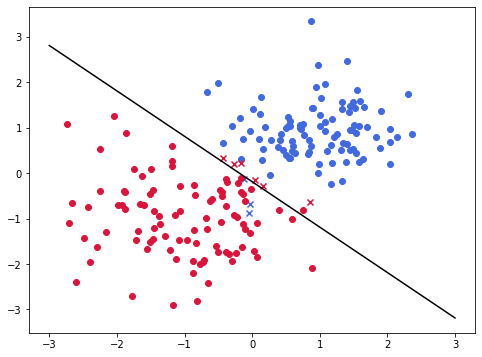

In [11]:
predicted = [classify(point, support_vector) for point in X]
colors = ["crimson" if label == 1 else "royalblue" for label in y]
markers= ["o" if label == predicted_label else "x" for label, predicted_label in zip (y, predicted)]
plt.figure(figsize=(8, 6))
for point, marker, color in zip(X, markers, colors):
  plt.scatter (point [0], point [1], color=color, marker=marker)
b, w = support_vector[0], support_vector [1:]
x1 = np.linspace (-3, 3, num=100)
x2 = -1 /w[1] * (w[1] * x1 + b)
plt.plot(x1, x2, "k-");

# Using SKlearn

In [12]:
from sklearn.svm import SVC # support vector classifier
model = SVC()
model.fit(X, y)
sk_predict = model.predict(X)

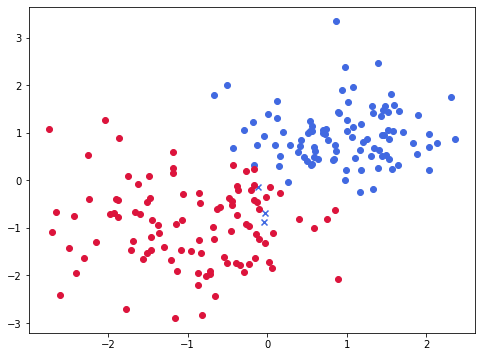

In [13]:
colors= ["crimson" if label == 1 else "royalblue" for label in y]
markers= ["o" if label == predicted_label else "x" for label, predicted_label in zip(y, sk_predict)]
plt.figure(figsize=(8, 6))
for point, marker, color in zip (X, markers, colors):
  plt.scatter (point[0], point [1], color=color, marker=marker)

# Non_Linear Data

In [14]:
def circle():
  num_points = 250
  points= 1-2*np.random.random((num_points, 2))
  radius = 0.6
  labels = [1 if np.linalg.norm(point)> radius else -1 for point in points]
  
  return points, labels

Text(0, 0.5, '$x 25')

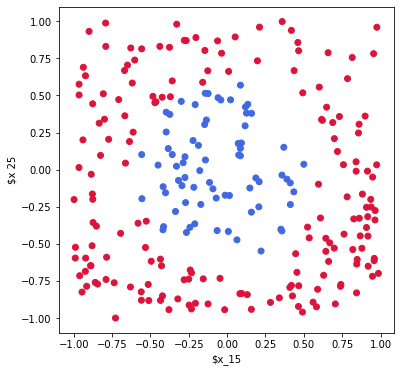

In [15]:
points, labels = circle()
colors = ["crimson" if label == 1 else "royalblue" for label in labels]
plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], color=colors)
plt.xlabel("$x_15")
plt.ylabel("$x 25")

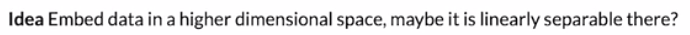

In [16]:
def feature_map(x): 
  return np.array([x[0], x[1], x[0] ** 2 + x[1] ** 2])

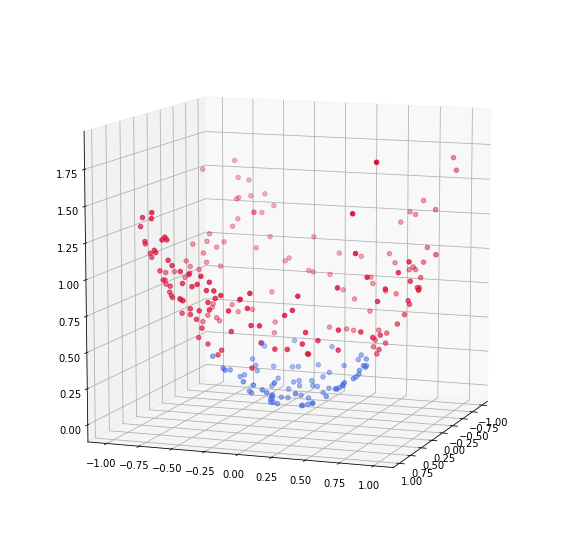

In [17]:
embedded_points = np.array([feature_map(point) for point in points])
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d') 
ax.scatter (embedded_points [:, 0], embedded_points[:, 1], embedded_points[:, 2], color=colors)
ax.view_init(10, 20)

Text(0, 0.5, '$x_2$')

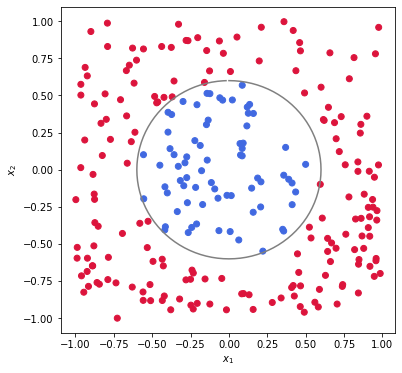

In [18]:
plt.figure(figsize=(6, 6)) 
plt.scatter (points[:, 0], points[:, 1], color=colors)
angles = np.linspace(0, 2* np.pi, num=200, endpoint=False)
x= 0.6*np.sin(angles)
y = 0.6* np.cos(angles)
plt.plot(x, y, color="grey")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

# Quantum SVM

In [19]:
pip install pylatexenc

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 KB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136833 sha256=cc49a65ffb4ac261eb740ed012e058e586df6030cfb4f512d8c799d7a7a9c6d5
  Stored in directory: /root/.cache/pip/wheels/72/99/be/81d9bcdf5dd5ee5acd8119a9dd5bc07204c9ce205fd341b021
Successfully built pylatexenc


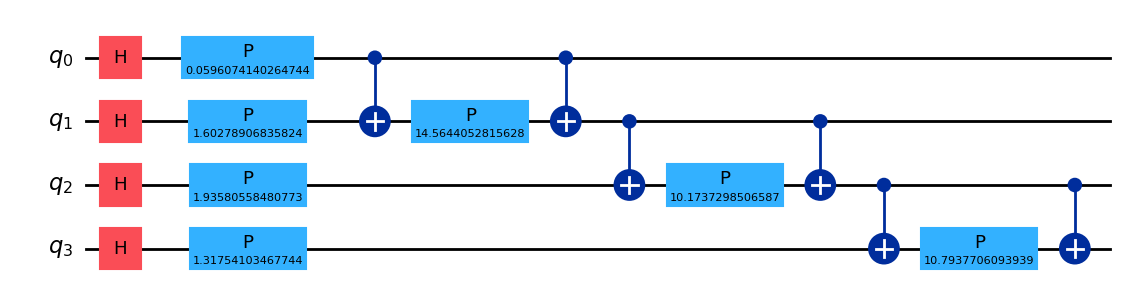

In [20]:
import numpy as np
from qiskit.circuit.library import ZZFeatureMap
#it  is called the ZZFeatureMap because it uses ZZ-rotations on two qubits
num_qubits=4
x = np.random.random(num_qubits)
data= ZZFeatureMap(feature_dimension=num_qubits, reps=1, entanglement="linear")  
# reps:parameter controls the number of times the ZZ-rotations are applied to the qubits.
#Entanglement between the qubits increases linearly as the number of qubits increases.
data.assign_parameters(x, inplace=True)
data.decompose().draw("mpl", style="iqx", scale=1.4)

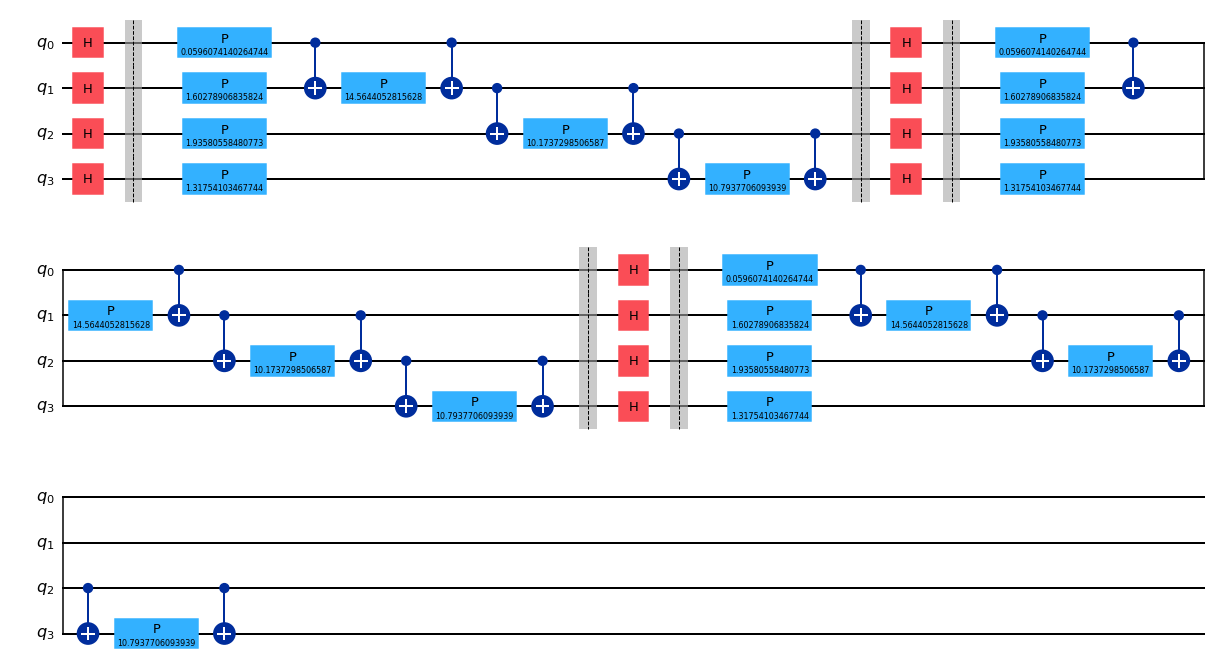

In [21]:
data= ZZFeatureMap(feature_dimension=num_qubits, reps=3, entanglement="linear", insert_barriers=True) 
data.assign_parameters(x, inplace=True) 
data.decompose().draw("mpl", style="iqx")

# Bulid Quantum kernel

In [22]:
from qiskit import transpile, BasicAer, QuantumCircuit
backend = BasicAer.get_backend("qasm_simulator")
shots = 1024
dimension = 2
feature_map = ZZFeatureMap(dimension, reps=1)
def evaluate_kernel(x_i, x_j):
  circuit=QuantumCircuit(dimension)
  circuit.compose(feature_map.assign_parameters(x_i), inplace=True)
  circuit.compose(feature_map.assign_parameters(x_j).inverse(), inplace=True)
  circuit.measure_all()

  transpiled= transpile(circuit, backend)
  counts=backend.run(transpiled, shots=shots).result().get_counts()

  return counts.get("0" * dimension, 0) / shots

In [23]:
evaluate_kernel(X[2], X[3])

0.1611328125


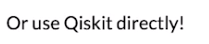

In [24]:
pip install qiskit_machine_learning

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 KB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 KB 13.3 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.6
    Uninstalling dill-0.3.6:
      Successfully uninstalled dill-0.3.6


In [25]:
from qiskit_machine_learning.kernels import QuantumKernel
kernel = QuantumKernel(feature_map, quantum_instance=backend) 
kernel.evaluate(X[2], X[3])

array([[0.14355469]])

Text(0, 0.5, 'sx 25')

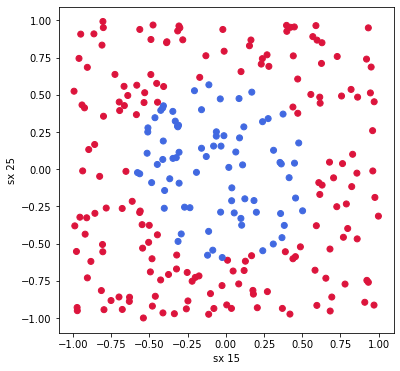

In [26]:
points, labels = circle()
colors= ["crimson" if label == 1 else "royalblue" for label in labels]
plt.figure(figsize=(6, 6))
plt.scatter (points[:, 0], points[:, 1], color=colors)
plt.xlabel("sx 15")
plt.ylabel("sx 25")

In [27]:
qsvm = SVC(kernel=kernel.evaluate)
qsvm.fit(points, labels) 
predicted = qsvm.predict(points)

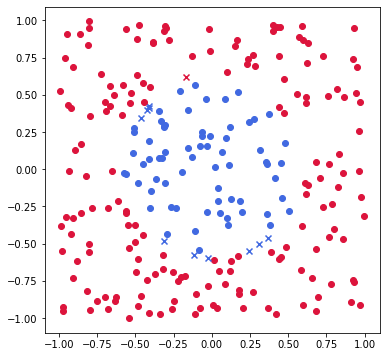

In [28]:
markers= ["o" if label == predicted_label else "x" for label, predicted_label in zip (labels, predicted)] 
plt.figure(figsize=(6, 6)) 
for point, marker, color in zip (points.tolist(), markers, colors):
  plt.scatter (point[0], point [1], color=color, marker=marker)

# Varitoinal Quantum Classifier

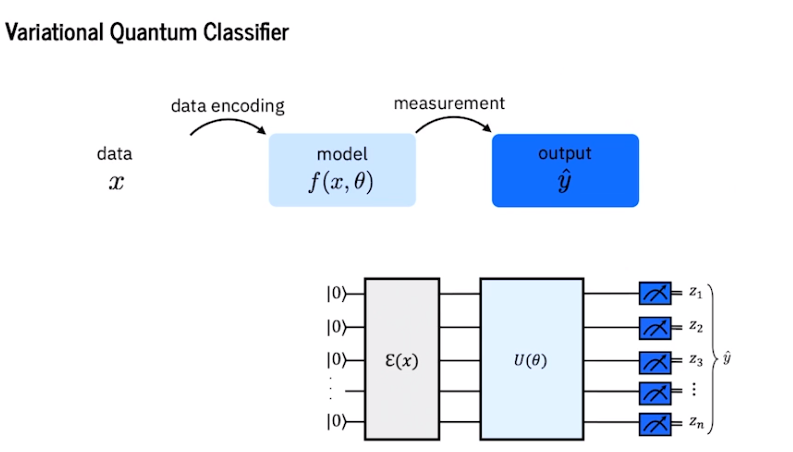

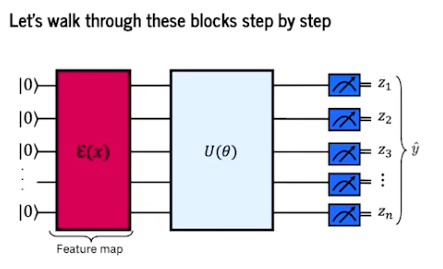

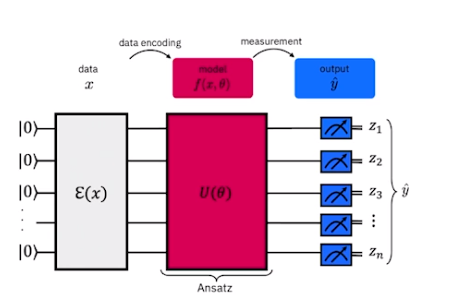

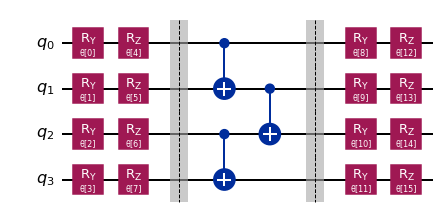

In [29]:
from qiskit.circuit. library import EfficientSU2 
ansatz = EfficientSU2 (num_qubits=4, reps=1, entanglement="pairwise", insert_barriers=True) 
ansatz.decompose().draw("mpl", style="iqx")

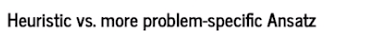

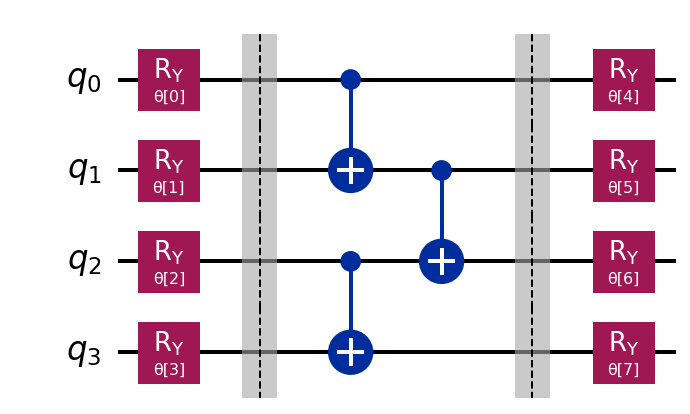

In [30]:
from qiskit.circuit. library import RealAmplitudes
ansatz=RealAmplitudes(num_qubits=4, reps=1, entanglement="pairwise", insert_barriers=True) 
ansatz.decompose().draw("mpl", style="iqx", scale = 2 )

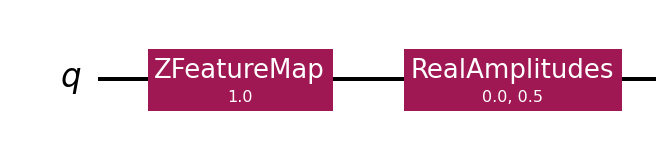

In [31]:
from qiskit.circuit. library import ZFeatureMap, RealAmplitudes
num_features=1
feature_map = ZFeatureMap(num_features)
model = RealAmplitudes (num_features, reps=1, entanglement="pairwise")
circuit = feature_map.compose(model)
data= np.array([1])
angles= np.arange(model.num_parameters) / model.num_parameters
bound= circuit.bind_parameters(np.concatenate((data, angles)))
bound.draw("mpl", style="iqx", scale=2)

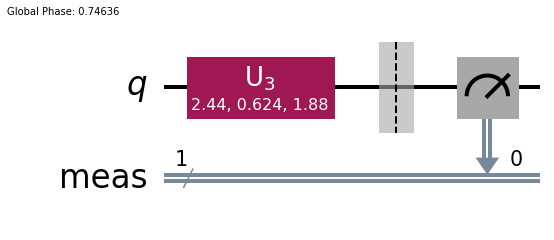

In [32]:
bound.measure_all()
backend = BasicAer.get_backend ("qasm_simulator") 
transpiled =transpile (bound, backend)
transpiled.draw("mpl", style="iqx", scale=2)

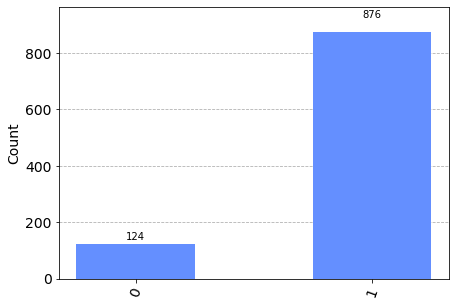

In [33]:
from qiskit.visualization import plot_histogram
result= backend.run(transpiled, shots=1000).result() 
counts = result.get_counts()
plot_histogram(counts)

In [34]:
def parity (bitstring): # return 1 if there's an even number of 1's, otherwise return -1 
   return 1 if bitstring.count("1") % 2 else -1
labels = {parity (bitstring): count / 1000 for bitstring, count in counts.items()} 
print(labels)

{1: 0.876, -1: 0.124}


## Slide related
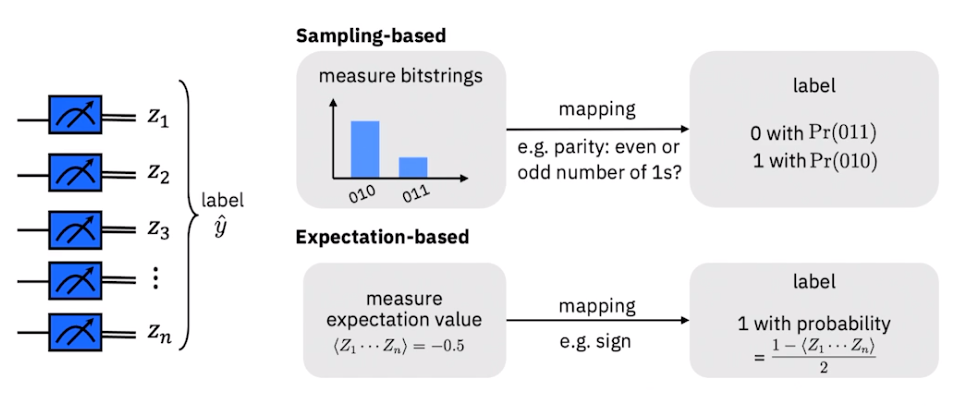

In [35]:
# define the expectation_value variable ((Not found in the Video))
expectation_value = - 0.5



In [36]:
probability_for_1 = (1 - expectation_value) / 2
expectation_labels = {1: probability_for_1, -1: 1- probability_for_1} 
print(expectation_labels)

{1: 0.75, -1: 0.25}


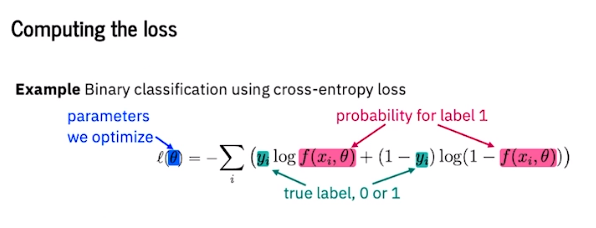

Text(0, 0.5, '$x_2$')

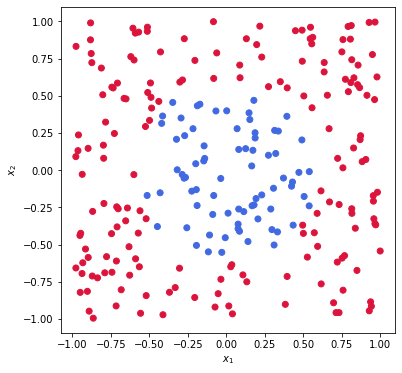

In [39]:
points, labels = circle()
colors= ["crimson" if label == 1 else "royalblue" for label in labels]
plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], color = colors)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

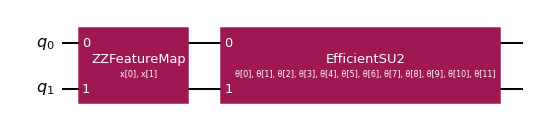

In [40]:
num_features = 2
feature_map=ZZFeatureMap (num_features, reps=3)
model = EfficientSU2(num_features, reps=2, entanglement="pairwise")
circuit.measure_all()
circuit = feature_map.compose (model) 
circuit.draw("mpl", style="iqx")

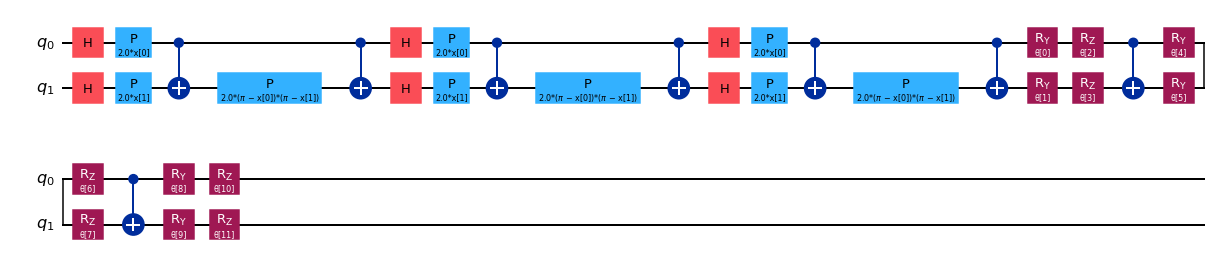

In [41]:
circuit.decompose().draw("mpl", style="iqx")

In [42]:
backend = BasicAer.get_backend("qasm_simulator") 
transpiled =transpile(circuit, backend) 
shots= 1000
def predict(theta, point, return_probabilities=False): 
  bound = transpiled.assign_parameters(np.concatenate((point, theta)))
  counts = backend. run (bound, shots-shots).result().get_counts()
  pr_1 = 0
  for bitstr, count in counts.items(): 
      if parity(bitstr) == 1: 
        pr_1 += count /shots
  if return_probabilities: 
        return pr_1
  return 1 if pr_1 > 0.5 else 0

In [ ]:
cutoff 1e-10
def safe_log(value):
return np.log(max (cutoff, value))
def loss (theta, x, y):
loss_value = 0
for Xi, yi in zip(x, y):
# probabilities for the predicted labels to be 1
pr_1= predict (theta, Xi, return_probabilities=True) loss_value = y_isafe_log(pr_1)+ (1 y_i) safe_log(1 - pr_1)
return loss_value